<a href="https://colab.research.google.com/github/Shresze/23BAI70375_23AIT_KRG_G1_FSD_2/blob/main/interpretable_skin_cancer_shap_publication_fast_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpretable Skin Cancer Diagnosis Using CNNs and SHAP
## Fast, publication-oriented Google Colab pipeline

This notebook keeps the **four original research novelties unchanged**:
1. **N1 — SHAP Faithfulness:** Insertion/Deletion AUC
2. **N2 — Model-Randomization Sanity Check**
3. **N3 — Synthetic Artifact-Attribution Bias Testing**
4. **N4 — Explanation Stability Under Perturbation**

The classifier/training pipeline is strengthened and the XAI experiments are batched to reduce runtime. No user upload, Google Drive, or Kaggle API token is required.

## Important scientific note

The notebook optimizes the **training and evaluation pipeline**, but it does not hard-code a target accuracy. Final performance must be measured on the held-out test set. The test set is used only once for final reporting.

The split is **lesion-grouped and stratified**, using `lesion_id`; it should not be described as patient-level unless a true patient identifier is available.

In [1]:
# ============================================================
# CELL 1 — CLEAN COLAB SETUP + AUTOMATIC HAM10000 DOWNLOAD
# ============================================================
# Fix Pillow/PIL mismatch without requiring a manual runtime restart.
import sys, subprocess, os, gc, warnings, shutil
from pathlib import Path

print("Installing/reparing required packages...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
    "--upgrade", "--force-reinstall", "Pillow==11.3.0"
])

# Remove stale PIL modules already loaded in this Python process.
for name in list(sys.modules):
    if name == "PIL" or name.startswith("PIL."):
        del sys.modules[name]
gc.collect()

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--upgrade",
    "kagglehub", "shap", "scipy", "scikit-learn", "pandas",
    "matplotlib", "seaborn", "tqdm"
])

from PIL import Image, ImageDraw, ImageEnhance
import PIL
print("Pillow:", PIL.__version__)
print("PIL import: OK")

# ------------------------------------------------------------
# Automatic HAM10000 download
# ------------------------------------------------------------
import kagglehub

KAGGLE_DATASET = "kmader/skin-cancer-mnist-ham10000"
print("\nChecking/downloading HAM10000...")

download_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
print("Dataset cache:", download_path)

metadata_candidates = list(download_path.rglob("HAM10000_metadata.csv"))
if not metadata_candidates:
    raise FileNotFoundError("HAM10000_metadata.csv was not found.")

METADATA_PATH = metadata_candidates[0]
DATA_ROOT = METADATA_PATH.parent

IMAGE_DIRS = sorted([
    p for p in download_path.rglob("*")
    if p.is_dir() and p.name.lower() in {
        "ham10000_images_part_1", "ham10000_images_part_2"
    }
])

# Robust fallback for mirrors with different directory names.
if len(IMAGE_DIRS) < 2:
    candidates = []
    for p in download_path.rglob("*"):
        if not p.is_dir():
            continue
        try:
            n = sum(1 for _ in p.glob("*.jpg"))
        except Exception:
            continue
        if n >= 100:
            candidates.append((n, p))
    candidates.sort(reverse=True)
    IMAGE_DIRS = sorted([p for _, p in candidates[:2]])

if len(IMAGE_DIRS) < 2:
    raise FileNotFoundError("Could not locate both HAM10000 image directories.")

# Compatibility path; do not duplicate the dataset.
CONTENT_ROOT = Path("/content/HAM10000")
if CONTENT_ROOT.is_symlink():
    CONTENT_ROOT.unlink()
elif CONTENT_ROOT.exists():
    try:
        shutil.rmtree(CONTENT_ROOT)
    except Exception:
        pass

try:
    CONTENT_ROOT.symlink_to(DATA_ROOT, target_is_directory=True)
    DISPLAY_ROOT = CONTENT_ROOT
except Exception:
    DISPLAY_ROOT = DATA_ROOT

n_images = sum(len(list(p.glob("*.jpg"))) for p in IMAGE_DIRS)
if n_images < 10000:
    raise RuntimeError(f"Expected about 10,015 images; found {n_images:,}.")

print("\nHAM10000 ready")
print("Root:", DISPLAY_ROOT)
print("Metadata:", METADATA_PATH)
print("Image directories:")
for p in IMAGE_DIRS:
    print(" -", p)
print(f"Total images: {n_images:,}")

Installing/reparing required packages...
Pillow: 11.3.0
PIL import: OK

Checking/downloading HAM10000...
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset cache: /kaggle/input/skin-cancer-mnist-ham10000

HAM10000 ready
Root: /content/HAM10000
Metadata: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Image directories:
 - /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1
 - /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2
 - /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1
 - /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2
Total images: 20,030


In [2]:
# ============================================================
# CELL 2 — IMPORTS + FAST RESEARCH CONFIGURATION
# ============================================================
import os, gc, copy, random, math, time, warnings, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageDraw, ImageEnhance
from tqdm.auto import tqdm

from scipy.stats import spearmanr, wilcoxon, ttest_rel
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_auc_score,
    average_precision_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import shap

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

IMAGE_SIZE = 224
NUM_CLASSES = 7
BATCH_SIZE = 64 if torch.cuda.is_available() else 16
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()
USE_AMP = torch.cuda.is_available()

# Stronger training, but early stopping prevents wasted epochs.
MAX_EPOCHS = 14 if torch.cuda.is_available() else 4
PATIENCE = 3
WARMUP_EPOCHS = 1
LR_BACKBONE = 1e-4
LR_HEAD = 5e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.04
UNFREEZE_FROM = 5  # EfficientNet feature blocks 5..8 become trainable.

# Fast but statistically useful XAI defaults. Increase these for a final
# high-powered study after the pipeline is verified.
SHAP_BACKGROUND_SIZE = 4
SHAP_NSAMPLES = 32
N1_IMAGES = 10 if torch.cuda.is_available() else 3
N2_IMAGES = 3 if torch.cuda.is_available() else 2
N3_IMAGES = 6 if torch.cuda.is_available() else 3
N4_IMAGES = 6 if torch.cuda.is_available() else 3
N1_STEPS = 10 if torch.cuda.is_available() else 6
N2_RANDOMIZATION_LEVELS = [0.0, 0.50, 1.0]

# Final test-time augmentation is reported separately from single-view.
USE_TTA = True

OUTPUT_DIR = Path("/content/skin_cancer_xai_outputs")
MODEL_DIR = OUTPUT_DIR / "models"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for d in [OUTPUT_DIR, MODEL_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "best_efficientnet_b0.pth"

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("SHAP:", shap.__version__)
print("Batch size:", BATCH_SIZE)
print("Max epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)
print("SHAP nsamples:", SHAP_NSAMPLES)
print("XAI samples N1/N2/N3/N4:", N1_IMAGES, N2_IMAGES, N3_IMAGES, N4_IMAGES)

Device: cpu
Torch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
SHAP: 0.52.0
Batch size: 16
Max epochs: 4
Early stopping patience: 3
SHAP nsamples: 32
XAI samples N1/N2/N3/N4: 3 2 3 3


In [3]:
# ============================================================
# CELL 3 — LOAD METADATA + BUILD IMAGE INDEX
# ============================================================
metadata = pd.read_csv(METADATA_PATH)
required = {"image_id", "dx", "lesion_id"}
missing = required - set(metadata.columns)
if missing:
    raise ValueError(f"Missing metadata columns: {missing}")

class_names = {
    "akiec": "Actinic keratoses",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}
label_map = {k: i for i, k in enumerate(class_names)}
metadata["label"] = metadata["dx"].map(label_map)

# O(1)-style lookup instead of scanning both folders for every row.
image_lookup = {}
for directory in IMAGE_DIRS:
    for p in directory.glob("*.jpg"):
        image_lookup[p.stem] = str(p)
metadata["image_path"] = metadata["image_id"].map(image_lookup)
metadata = metadata.dropna(subset=["image_path", "label"]).reset_index(drop=True)
metadata["label"] = metadata["label"].astype(int)

print("Usable images:", len(metadata))
display(metadata["dx"].value_counts().rename("count").to_frame())

Usable images: 10015


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [4]:
# ============================================================
# CELL 4 — STRATIFIED GROUPED 70/15/15 SPLIT
# ============================================================
# 20 stratified group folds allow an approximately 70/15/15 split while
# keeping lesion_id groups together.
sgkf = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=SEED)
fold_id = np.full(len(metadata), -1, dtype=int)

for f, (_, idx) in enumerate(
    sgkf.split(metadata, metadata["label"], groups=metadata["lesion_id"])
):
    fold_id[idx] = f

metadata["fold"] = fold_id

# Choose 3 folds for test and 3 remaining folds for validation. We select
# combinations whose class proportions are closest to the full dataset.
from itertools import combinations

def fold_profile(folds):
    subset = metadata[metadata["fold"].isin(folds)]
    counts = subset["label"].value_counts().reindex(range(NUM_CLASSES), fill_value=0).values
    return counts, len(subset)

global_counts = metadata["label"].value_counts().reindex(range(NUM_CLASSES), fill_value=0).values

global_prop = global_counts / global_counts.sum()

def score_combo(combo):
    counts, n = fold_profile(combo)
    prop = counts / max(n, 1)
    # Class-distribution distance plus small size penalty.
    dist = np.mean(np.abs(prop - global_prop))
    size_penalty = abs(n / len(metadata) - 0.15)
    missing_penalty = np.sum(counts == 0) * 0.05
    return dist + size_penalty + missing_penalty

all_combos = list(combinations(range(20), 3))
test_folds = min(all_combos, key=score_combo)
remaining = [f for f in range(20) if f not in test_folds]
val_folds = min(combinations(remaining, 3), key=score_combo)
train_folds = [f for f in range(20) if f not in test_folds and f not in val_folds]

train_df = metadata[metadata["fold"].isin(train_folds)].copy().reset_index(drop=True)
val_df = metadata[metadata["fold"].isin(val_folds)].copy().reset_index(drop=True)
test_df = metadata[metadata["fold"].isin(test_folds)].copy().reset_index(drop=True)

assert set(train_df.lesion_id).isdisjoint(val_df.lesion_id)
assert set(train_df.lesion_id).isdisjoint(test_df.lesion_id)
assert set(val_df.lesion_id).isdisjoint(test_df.lesion_id)

split_table = pd.DataFrame({
    "Train": train_df.dx.value_counts(),
    "Validation": val_df.dx.value_counts(),
    "Test": test_df.dx.value_counts()
}).reindex(class_names.keys()).fillna(0).astype(int)

display(split_table)
print("Train:", len(train_df), "Validation:", len(val_df), "Test:", len(test_df))
print("Test folds:", test_folds, "Validation folds:", val_folds)
split_table.to_csv(TABLE_DIR / "split_class_distribution.csv")

,Train,Validation,Test
dx,,,
akiec,229,49,49
bcc,360,77,77
bkl,769,165,165
df,81,17,17
mel,779,167,167
nv,4693,1006,1006
vasc,100,21,21


Train: 7011 Validation: 1502 Test: 1502
Test folds: (0, 3, 13) Validation folds: (1, 10, 16)


In [5]:
# ============================================================
# CELL 5 — AUGMENTATION + DATASET + DATALOADERS
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class SkinDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as im:
            image = im.convert("RGB")
        return self.transform(image), int(row["label"]), idx

train_dataset = SkinDataset(train_df, train_transform)
val_dataset = SkinDataset(val_df, eval_transform)
test_dataset = SkinDataset(test_df, eval_transform)

loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("Dataloaders ready.")

Dataloaders ready.


In [6]:
# ============================================================
# CELL 6 — EFFICIENTNET-B0 + MILD CLASS-BALANCED LOSS
# ============================================================
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, NUM_CLASSES)
)
model = model.to(DEVICE)

# Mild effective balancing: avoids the extreme inverse-frequency weighting
# that caused the previous model to over-favor minority classes.
counts = train_df["label"].value_counts().reindex(range(NUM_CLASSES), fill_value=0).values.astype(float)
raw_w = np.sqrt(len(train_df) / (NUM_CLASSES * np.maximum(counts, 1)))
class_weights = np.clip(raw_w / raw_w.mean(), 0.50, 2.50)
class_weights = class_weights / class_weights.mean()

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE),
    label_smoothing=LABEL_SMOOTHING
)

# Start with the classifier plus last EfficientNet blocks trainable.
for p in model.features.parameters():
    p.requires_grad = False
for p in model.features[UNFREEZE_FROM:].parameters():
    p.requires_grad = True
for p in model.classifier.parameters():
    p.requires_grad = True

def make_optimizer():
    backbone_params = [
        p for p in model.features[UNFREEZE_FROM:].parameters() if p.requires_grad
    ]
    head_params = [p for p in model.classifier.parameters() if p.requires_grad]
    return optim.AdamW([
        {"params": backbone_params, "lr": LR_BACKBONE},
        {"params": head_params, "lr": LR_HEAD}
    ], weight_decay=WEIGHT_DECAY)

optimizer = make_optimizer()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(MAX_EPOCHS, 1), eta_min=1e-6)

print("Class weights:", np.round(class_weights, 3))
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]


Class weights: [1.072 0.855 0.585 1.802 0.581 0.482 1.622]
Trainable parameters: 3707855


In [7]:
# ============================================================
# CELL 7 — TRAIN/EVALUATION FUNCTIONS
# ============================================================
if hasattr(torch, "amp"):
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
else:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def autocast_context():
    if hasattr(torch, "amp"):
        return torch.amp.autocast("cuda", enabled=USE_AMP)
    return torch.cuda.amp.autocast(enabled=USE_AMP)

def train_one_epoch():
    model.train()
    running_loss = 0.0
    correct = total = 0
    for images, labels, _ in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / max(total, 1), correct / max(total, 1)

@torch.inference_mode()
def predict_loader(loader, tta=False):
    model.eval()
    ys, ps, probs = [], [], []
    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        with autocast_context():
            logits = model(images)
            if tta:
                flip_logits = model(torch.flip(images, dims=[3]))
                logits = 0.5 * (logits + flip_logits)
            p = torch.softmax(logits, dim=1)
        ys.append(labels.numpy())
        ps.append(p.argmax(1).cpu().numpy())
        probs.append(p.float().cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

def metrics_from_arrays(y_true, y_pred, y_prob):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), average="macro", zero_division=0
    )
    try:
        macro_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        macro_auc = np.nan
    try:
        macro_ap = average_precision_score(
            np.eye(NUM_CLASSES)[y_true], y_prob, average="macro"
        )
    except Exception:
        macro_ap = np.nan
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "macro_roc_auc_ovr": macro_auc,
        "macro_auprc": macro_ap,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [8]:
# ============================================================
# CELL 8 — TRAIN WITH BEST VALIDATION MACRO-F1 + EARLY STOPPING
# ============================================================
best_f1 = -np.inf
best_epoch = 0
patience_counter = 0
history = []

for epoch in range(MAX_EPOCHS):
    # After one warm-up epoch, all feature blocks are fine-tuned with a
    # small learning rate. This gives the pretrained representation time
    # to adapt without spending many epochs on a frozen classifier.
    if epoch == WARMUP_EPOCHS:
        for p in model.features.parameters():
            p.requires_grad = True
        optimizer = optim.AdamW([
            {"params": model.features.parameters(), "lr": LR_BACKBONE},
            {"params": model.classifier.parameters(), "lr": LR_HEAD}
        ], weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(MAX_EPOCHS - epoch, 1), eta_min=1e-6
        )
        print("Unfroze full EfficientNet backbone for fine-tuning.")

    t0 = time.time()
    train_loss, train_acc = train_one_epoch()
    yv, pv, probv = predict_loader(val_loader, tta=False)
    val = metrics_from_arrays(yv, pv, probv)
    scheduler.step()

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_accuracy": val["accuracy"],
        "val_macro_precision": val["macro_precision"],
        "val_macro_recall": val["macro_recall"],
        "val_macro_f1": val["macro_f1"],
        "val_macro_roc_auc": val["macro_roc_auc_ovr"],
        "val_macro_auprc": val["macro_auprc"],
        "seconds": time.time() - t0
    }
    history.append(row)

    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"train_acc={train_acc:.3f} | val_acc={val['accuracy']:.3f} | "
        f"val_macroF1={val['macro_f1']:.3f} | val_AUC={val['macro_roc_auc_ovr']:.3f} | "
        f"{row['seconds']:.1f}s"
    )

    if val["macro_f1"] > best_f1 + 1e-4:
        best_f1 = val["macro_f1"]
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print("  -> best checkpoint saved")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("  -> early stopping")
            break

history_df = pd.DataFrame(history)
history_df.to_csv(TABLE_DIR / "training_history.csv", index=False)
print("Best validation Macro-F1:", round(best_f1, 4), "at epoch", best_epoch)

Epoch 01/4 | train_acc=0.736 | val_acc=0.785 | val_macroF1=0.561 | val_AUC=0.938 | 717.1s
  -> best checkpoint saved
Unfroze full EfficientNet backbone for fine-tuning.
Epoch 02/4 | train_acc=0.805 | val_acc=0.821 | val_macroF1=0.669 | val_AUC=0.955 | 1023.1s
  -> best checkpoint saved
Epoch 03/4 | train_acc=0.840 | val_acc=0.832 | val_macroF1=0.711 | val_AUC=0.959 | 1024.9s
  -> best checkpoint saved
Epoch 04/4 | train_acc=0.866 | val_acc=0.839 | val_macroF1=0.719 | val_AUC=0.962 | 1026.1s
  -> best checkpoint saved
Best validation Macro-F1: 0.7186 at epoch 4


In [9]:
# ============================================================
# CELL 9 — FINAL TEST EVALUATION (SINGLE VIEW + OPTIONAL TTA)
# ============================================================
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

y_true, y_pred, y_prob = predict_loader(test_loader, tta=False)
test_single = metrics_from_arrays(y_true, y_pred, y_prob)

if USE_TTA:
    y_true_tta, y_pred_tta, y_prob_tta = predict_loader(test_loader, tta=True)
    test_tta = metrics_from_arrays(y_true_tta, y_pred_tta, y_prob_tta)
else:
    test_tta = test_single

summary = pd.DataFrame([
    {"evaluation": "Single-view", **{k: test_single[k] for k in ["accuracy","macro_precision","macro_recall","macro_f1","macro_roc_auc_ovr","macro_auprc"]}},
    {"evaluation": "Horizontal-flip TTA", **{k: test_tta[k] for k in ["accuracy","macro_precision","macro_recall","macro_f1","macro_roc_auc_ovr","macro_auprc"]}}
])
display(summary.style.format({c: "{:.4f}" for c in summary.columns if c != "evaluation"}))
summary.to_csv(TABLE_DIR / "test_summary_single_vs_tta.csv", index=False)

# Use the stronger TTA output for the main downstream report, while retaining
# single-view metrics transparently in the saved table.
test_metrics = test_tta

print("\nClassification report (TTA):")
print(classification_report(
    test_metrics["y_true"], test_metrics["y_pred"],
    labels=list(range(NUM_CLASSES)),
    target_names=list(class_names.values()),
    digits=4, zero_division=0
))

,evaluation,accuracy,macro_precision,macro_recall,macro_f1,macro_roc_auc_ovr,macro_auprc
0,Single-view,0.8322,0.6928,0.6934,0.6852,0.9586,0.7528
1,Horizontal-flip TTA,0.8302,0.6914,0.6938,0.6814,0.9612,0.7693



Classification report (TTA):
                      precision    recall  f1-score   support

   Actinic keratoses     0.5574    0.6939    0.6182        49
Basal cell carcinoma     0.6591    0.7532    0.7030        77
    Benign keratosis     0.7956    0.6606    0.7219       165
      Dermatofibroma     0.7500    0.5294    0.6207        17
            Melanoma     0.5983    0.4192    0.4930       167
    Melanocytic nevi     0.8987    0.9433    0.9205      1006
    Vascular lesions     0.5806    0.8571    0.6923        21

            accuracy                         0.8302      1502
           macro avg     0.6914    0.6938    0.6814      1502
        weighted avg     0.8244    0.8302    0.8235      1502



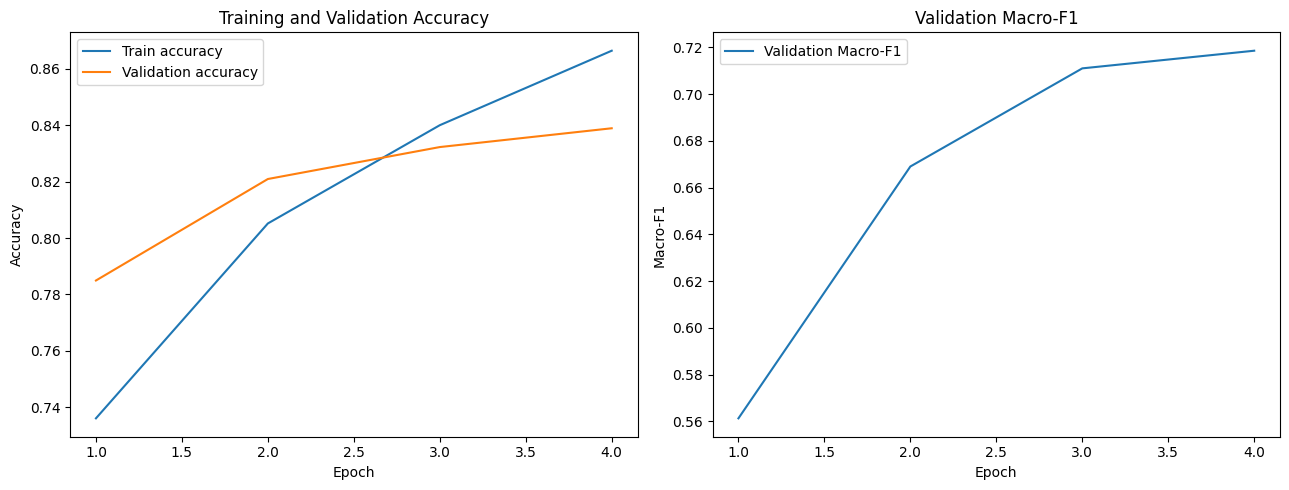

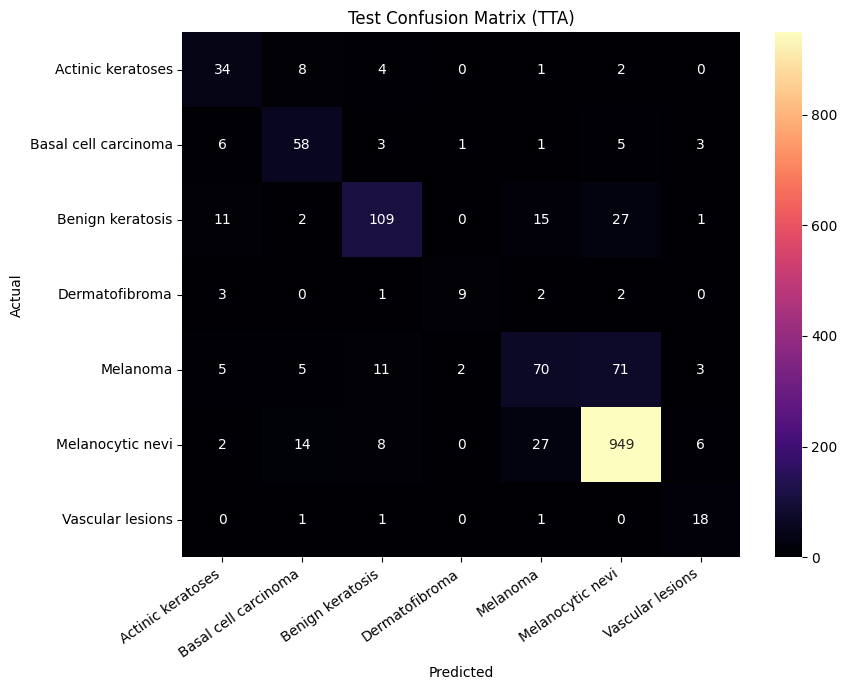

In [10]:
# ============================================================
# CELL 10 — CURVES + CONFUSION MATRIX
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
h = history_df
axes[0].plot(h["epoch"], h["train_accuracy"], label="Train accuracy")
axes[0].plot(h["epoch"], h["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(h["epoch"], h["val_macro_f1"], label="Validation Macro-F1")
axes[1].set_title("Validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves.png", dpi=300)
plt.show()

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"], labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=class_names.values(), yticklabels=class_names.values())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix (TTA)")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "test_confusion_matrix.png", dpi=300)
plt.show()

# SHAP explanation engine

`GradientExplainer` is retained. The implementation below reduces runtime by:
- using a small background set;
- using a controlled `nsamples` value;
- explaining **batches** of images whenever the target class is shared;
- reusing the same SHAP computation for N3/N4 perturbation sets.

In [11]:
# ============================================================
# CELL 11 — SHAP BACKGROUND + ROBUST SHAP HELPERS
# ============================================================
model.eval()
background = []
for i in range(min(SHAP_BACKGROUND_SIZE, len(train_df))):
    row = train_df.iloc[i]
    with Image.open(row["image_path"]) as im:
        background.append(eval_transform(im.convert("RGB")))
background = torch.stack(background).to(DEVICE)
shap_explainer = shap.GradientExplainer(
    model, background, batch_size=min(4, len(background)), local_smoothing=0
)


def shap_maps(explainer, tensors, target_class):
    """Return one normalized HxW absolute-SHAP map per tensor."""
    if not torch.is_tensor(tensors):
        tensors = torch.stack(tensors)
    tensors = tensors.to(DEVICE)
    if tensors.ndim == 3:
        tensors = tensors.unsqueeze(0)

    sv = explainer.shap_values(
        tensors, nsamples=SHAP_NSAMPLES, rseed=SEED
    )
    arr = np.asarray(sv) if not isinstance(sv, list) else None

    if isinstance(sv, list):
        # list[class] -> N,C,H,W in common PyTorch SHAP versions
        arr = np.asarray(sv[target_class])
        if arr.ndim == 3:
            arr = arr[None, ...]
    else:
        # Common current SHAP layout: N,C,H,W,K
        if arr.ndim == 5:
            if arr.shape[-1] == NUM_CLASSES:
                arr = arr[..., target_class]
            elif arr.shape[1] == NUM_CLASSES:
                arr = arr[:, target_class, ...]
            else:
                raise ValueError(f"Unsupported SHAP shape: {arr.shape}")
        elif arr.ndim == 4:
            pass
        else:
            raise ValueError(f"Unsupported SHAP shape: {arr.shape}")

    if arr.ndim != 4:
        raise ValueError(f"Unexpected SHAP shape after target selection: {arr.shape}")

    # Convert N,C,H,W -> N,H,W,C if channel-first.
    if arr.shape[1] in (1, 3) and arr.shape[-1] not in (1, 3):
        arr = np.transpose(arr, (0, 2, 3, 1))

    if arr.shape[-1] not in (1, 3):
        raise ValueError(f"Could not identify channel axis: {arr.shape}")

    maps = np.abs(arr).mean(axis=-1)
    maps = np.nan_to_num(maps, nan=0.0, posinf=0.0, neginf=0.0)
    out = []
    for m in maps:
        m = m - m.min()
        mx = m.max()
        if mx > 0:
            m = m / mx
        out.append(m.astype(np.float32))
    return np.stack(out)

@torch.inference_mode()
def predict_tensor(tensor, tta=False):
    model.eval()
    x = tensor.to(DEVICE)
    with autocast_context():
        logits = model(x)
        if tta:
            logits = 0.5 * (logits + model(torch.flip(x, dims=[3])))
        probs = torch.softmax(logits, dim=1)
    pred = int(probs.argmax(1).item())
    return pred, float(probs[0, pred].item()), probs[0].float().cpu().numpy()

def denormalize(tensor):
    x = tensor.detach().cpu().squeeze(0).numpy().transpose(1,2,0)
    x = x * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(x, 0, 1)

print("SHAP explainer ready.")

SHAP explainer ready.


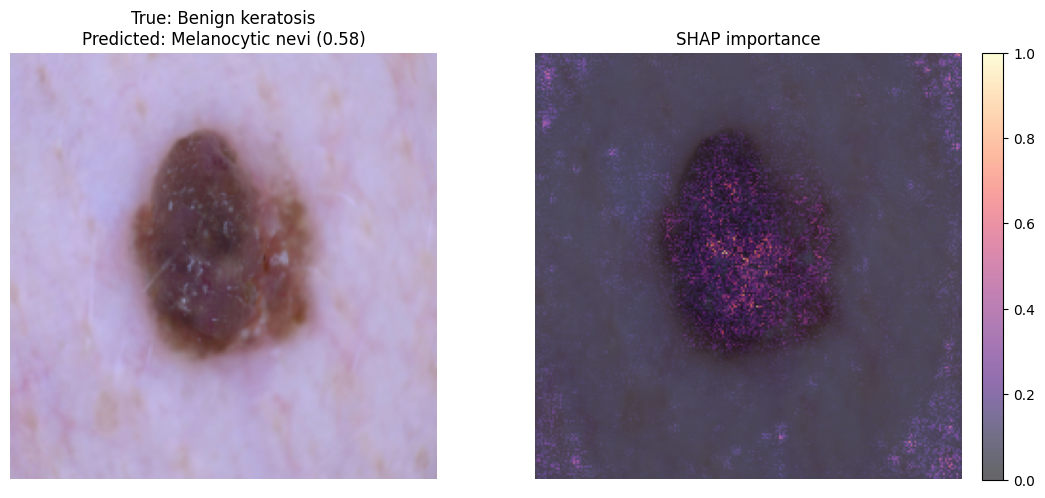

In [12]:
# ============================================================
# CELL 12 — REPRESENTATIVE SHAP VISUALIZATION
# ============================================================
row = test_df.iloc[0]
with Image.open(row["image_path"]) as im:
    pil = im.convert("RGB")
tensor = eval_transform(pil).unsqueeze(0)
pred, conf, _ = predict_tensor(tensor, tta=True)
shap_map = shap_maps(shap_explainer, tensor, pred)[0]
visual = denormalize(tensor)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(visual)
ax[0].axis("off")
ax[0].set_title(f"True: {class_names[row.dx]}\nPredicted: {list(class_names.values())[pred]} ({conf:.2f})")
ax[1].imshow(visual)
im = ax[1].imshow(shap_map, alpha=0.60, cmap="magma")
ax[1].axis("off")
ax[1].set_title("SHAP importance")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "example_shap.png", dpi=300)
plt.show()

# NOVELTY 1 — SHAP Faithfulness

The original **Insertion/Deletion AUC** protocol is preserved. Lower deletion AUC and higher insertion AUC are generally preferable under this protocol.

In [13]:
# ============================================================
# CELL 13 — N1 FUNCTIONS (BATCHED)
# ============================================================
def target_probabilities(tensors, target_class, batch_size=64):
    outputs = []
    model.eval()
    for start in range(0, len(tensors), batch_size):
        b = tensors[start:start+batch_size].to(DEVICE)
        with torch.inference_mode(), autocast_context():
            p = torch.softmax(model(b), dim=1)[:, target_class]
        outputs.append(p.float().cpu().numpy())
    return np.concatenate(outputs)

def deletion_curve(tensor, importance, target_class, steps=N1_STEPS):
    image = tensor.squeeze(0).cpu().numpy()
    ranking = np.argsort(importance.reshape(-1))[::-1]
    c, h, w = image.shape
    batch = []
    for s in range(steps + 1):
        n = int((s / steps) * len(ranking))
        x = image.copy().reshape(c, -1)
        if n:
            x[:, ranking[:n]] = 0.0
        batch.append(torch.from_numpy(x.reshape(c,h,w)).float())
    return target_probabilities(torch.stack(batch), target_class)

def insertion_curve(tensor, importance, target_class, steps=N1_STEPS):
    image = tensor.squeeze(0).cpu().numpy()
    ranking = np.argsort(importance.reshape(-1))[::-1]
    c, h, w = image.shape
    batch = []
    for s in range(steps + 1):
        n = int((s / steps) * len(ranking))
        x = np.zeros_like(image).reshape(c, -1)
        if n:
            src = image.reshape(c, -1)
            x[:, ranking[:n]] = src[:, ranking[:n]]
        batch.append(torch.from_numpy(x.reshape(c,h,w)).float())
    return target_probabilities(torch.stack(batch), target_class)

def curve_auc(values):
    return float(np.trapezoid(values, np.linspace(0,1,len(values))) if hasattr(np, "trapezoid") else np.trapz(values, np.linspace(0,1,len(values))))

In [14]:
# ============================================================
# CELL 14 — N1 EXPERIMENT
# ============================================================
n1_records = []
for i in tqdm(range(min(N1_IMAGES, len(test_df))), desc="N1 Faithfulness"):
    row = test_df.iloc[i]
    with Image.open(row["image_path"]) as im:
        tensor = eval_transform(im.convert("RGB")).unsqueeze(0)
    pred, conf, _ = predict_tensor(tensor, tta=False)
    imp = shap_maps(shap_explainer, tensor, pred)[0]
    deletion = deletion_curve(tensor, imp, pred)
    insertion = insertion_curve(tensor, imp, pred)
    n1_records.append({
        "index": i, "true_class": row.dx, "predicted_class": pred,
        "confidence": conf, "deletion_auc": curve_auc(deletion),
        "insertion_auc": curve_auc(insertion)
    })
n1_df = pd.DataFrame(n1_records)
n1_df.to_csv(TABLE_DIR / "novelty1_faithfulness.csv", index=False)
display(n1_df)

N1 Faithfulness:   0%|          | 0/3 [00:00<?, ?it/s]

,index,true_class,predicted_class,confidence,deletion_auc,insertion_auc
0,0,bkl,5,0.557595,0.460551,0.369097
1,1,bkl,5,0.799136,0.495598,0.425775
2,2,bkl,2,0.892674,0.304503,0.309234


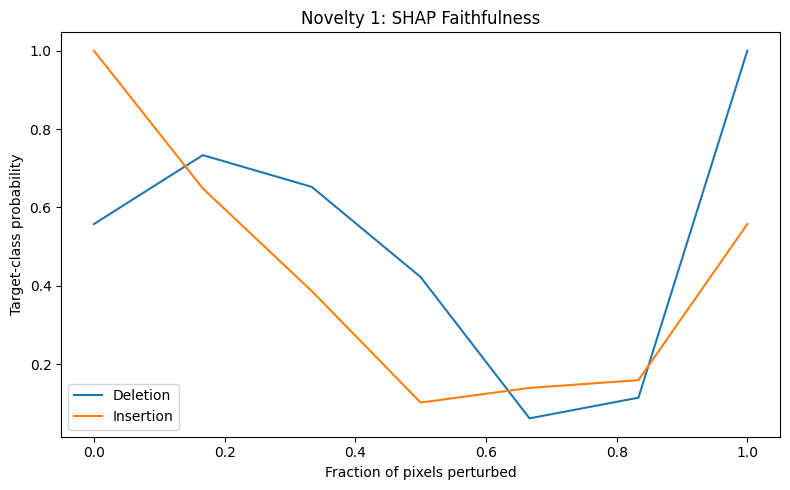

In [15]:
# ============================================================
# CELL 15 — N1 CURVE
# ============================================================
if len(n1_df):
    r = n1_df.iloc[0]
    row = test_df.iloc[int(r["index"])]
    with Image.open(row["image_path"]) as im:
        tensor = eval_transform(im.convert("RGB")).unsqueeze(0)
    pred, _, _ = predict_tensor(tensor)
    imp = shap_maps(shap_explainer, tensor, pred)[0]
    deletion = deletion_curve(tensor, imp, pred)
    insertion = insertion_curve(tensor, imp, pred)
    x = np.linspace(0,1,len(deletion))
    plt.figure(figsize=(8,5))
    plt.plot(x, deletion, label="Deletion")
    plt.plot(x, insertion, label="Insertion")
    plt.xlabel("Fraction of pixels perturbed")
    plt.ylabel("Target-class probability")
    plt.title("Novelty 1: SHAP Faithfulness")
    plt.legend(); plt.tight_layout()
    plt.savefig(FIG_DIR / "novelty1_insertion_deletion.png", dpi=300)
    plt.show()

# NOVELTY 2 — Model-Randomization Sanity Check

The original progressive model-randomization idea is preserved. SHAP explanations are compared against the trained model explanation as increasingly large portions of the learned feature extractor are randomized.

In [16]:
# ============================================================
# CELL 16 — N2 FUNCTIONS
# ============================================================
def reset_module_parameters(module):
    for child in module.children():
        reset_module_parameters(child)
    if hasattr(module, "reset_parameters"):
        try:
            module.reset_parameters()
        except Exception:
            pass

def randomized_copy(source_model):
    m = copy.deepcopy(source_model).to(DEVICE)
    m.eval()
    return m

def randomize_last_feature_blocks(source_model, fraction):
    m = randomized_copy(source_model)
    if fraction <= 0:
        return m
    blocks = list(m.features.children())
    n = max(1, int(np.ceil(fraction * len(blocks))))
    for block in blocks[-n:]:
        reset_module_parameters(block)
    reset_module_parameters(m.classifier)
    m.eval()
    return m

def make_explainer_for_model(m):
    return shap.GradientExplainer(
        m, background, batch_size=min(4, len(background)), local_smoothing=0
    )

def spearman_map(a,b):
    a = np.asarray(a).reshape(-1); b = np.asarray(b).reshape(-1)
    v, _ = spearmanr(a,b)
    return float(v) if np.isfinite(v) else np.nan

In [17]:
# ============================================================
# CELL 17 — N2 EXPERIMENT (REDUCED LEVELS + SMALL N, SAME NOVELTY)
# ============================================================
n2_records = []
for i in tqdm(range(min(N2_IMAGES, len(test_df))), desc="N2 Randomization"):
    row = test_df.iloc[i]
    with Image.open(row["image_path"]) as im:
        tensor = eval_transform(im.convert("RGB")).unsqueeze(0)
    original_pred, original_conf, _ = predict_tensor(tensor, tta=False)
    original_map = shap_maps(shap_explainer, tensor, original_pred)[0]

    for fraction in N2_RANDOMIZATION_LEVELS:
        if fraction == 0:
            rand_model = model
            rand_explainer = shap_explainer
        else:
            rand_model = randomize_last_feature_blocks(model, fraction)
            rand_explainer = make_explainer_for_model(rand_model)
        rand_map = shap_maps(rand_explainer, tensor, original_pred)[0]
        n2_records.append({
            "index": i,
            "randomized_fraction": fraction,
            "original_predicted_class": original_pred,
            "original_confidence": original_conf,
            "shap_spearman_similarity": spearman_map(original_map, rand_map)
        })
        if fraction != 0:
            del rand_model, rand_explainer
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

n2_df = pd.DataFrame(n2_records)
n2_df.to_csv(TABLE_DIR / "novelty2_randomization.csv", index=False)
display(n2_df)

N2 Randomization:   0%|          | 0/2 [00:00<?, ?it/s]

,index,randomized_fraction,original_predicted_class,original_confidence,shap_spearman_similarity
0,0,0.0,5,0.557595,1.000000
1,0,0.5,5,0.557595,0.363703
2,0,1.0,5,0.557595,0.375163
3,1,0.0,5,0.799136,1.000000
4,1,0.5,5,0.799136,0.225959
5,1,1.0,5,0.799136,0.173802


,randomized_fraction,count,mean,std,sem,ci95_lower,ci95_upper
0,0.0,2,1.000000,0.000000,0.000000,1.000000,1.000000
1,0.5,2,0.294831,0.097400,0.068872,0.159842,0.429820
2,1.0,2,0.274483,0.142383,0.100680,0.077149,0.471816


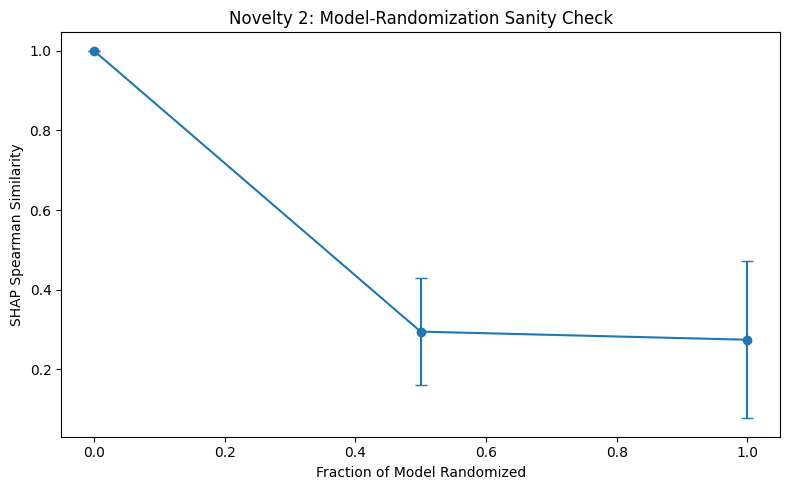

In [19]:
# ============================================================
# CELL 18 — N2 SUMMARY
# ============================================================

# Summary statistics
n2_summary = (
    n2_df
    .groupby("randomized_fraction")["shap_spearman_similarity"]
    .agg(["count", "mean", "std"])
    .reset_index()
)

# Standard error
n2_summary["sem"] = (
    n2_summary["std"]
    / np.sqrt(n2_summary["count"].clip(lower=1))
)

# 95% confidence interval
n2_summary["ci95_lower"] = (
    n2_summary["mean"]
    - 1.96 * n2_summary["sem"]
)

n2_summary["ci95_upper"] = (
    n2_summary["mean"]
    + 1.96 * n2_summary["sem"]
)

# Display table
display(n2_summary)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    n2_summary["randomized_fraction"],
    n2_summary["mean"],
    yerr=1.96 * n2_summary["sem"],   # FIXED: use ["sem"]
    marker="o",
    capsize=4
)

plt.xlabel("Fraction of Model Randomized")
plt.ylabel("SHAP Spearman Similarity")
plt.title("Novelty 2: Model-Randomization Sanity Check")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "novelty2_randomization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# ============================================================
# SAVE COMPLETE RESEARCH STATE AFTER N2
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import torch
import pandas as pd
import json
import shutil
import os

SAVE_ROOT = Path(
    "/content/drive/MyDrive/skin_cancer_research_checkpoint"
)

SAVE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("SAVING COMPLETE RESEARCH STATE AFTER N2")
print("=" * 70)

# ------------------------------------------------------------
# 1. SAVE BEST MODEL
# ------------------------------------------------------------

model_path = SAVE_ROOT / "best_model_after_training.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "epoch": epoch if "epoch" in globals() else None,
        "class_names": (
            class_names
            if "class_names" in globals()
            else None
        ),
    },
    model_path
)

print(f"Model saved: {model_path}")

# ------------------------------------------------------------
# 2. SAVE N1 RESULTS
# ------------------------------------------------------------

n1_saved = False

for variable_name in [
    "n1_df",
    "n1_results_df",
    "n1_results"
]:

    if variable_name in globals():

        obj = globals()[variable_name]

        try:

            if isinstance(obj, pd.DataFrame):
                df = obj

            else:
                df = pd.DataFrame(obj)

            df.to_csv(
                SAVE_ROOT / "N1_faithfulness_results.csv",
                index=False
            )

            print(
                f"N1 results saved: "
                f"{len(df)} rows"
            )

            n1_saved = True
            break

        except Exception as e:

            print(
                f"Could not save {variable_name}: {e}"
            )

if not n1_saved:
    print("WARNING: N1 dataframe was not found.")

# ------------------------------------------------------------
# 3. SAVE N2 RESULTS
# ------------------------------------------------------------

n2_saved = False

for variable_name in [
    "n2_df",
    "n2_results_df",
    "n2_results"
]:

    if variable_name in globals():

        obj = globals()[variable_name]

        try:

            if isinstance(obj, pd.DataFrame):
                df = obj

            else:
                df = pd.DataFrame(obj)

            df.to_csv(
                SAVE_ROOT / "N2_randomization_results.csv",
                index=False
            )

            print(
                f"N2 results saved: "
                f"{len(df)} rows"
            )

            n2_saved = True
            break

        except Exception as e:

            print(
                f"Could not save {variable_name}: {e}"
            )

if not n2_saved:
    print("WARNING: N2 dataframe was not found.")

# ------------------------------------------------------------
# 4. SAVE TRAINING HISTORY
# ------------------------------------------------------------

if "history" in globals():

    try:

        with open(
            SAVE_ROOT / "training_history.json",
            "w"
        ) as f:

            json.dump(
                history,
                f,
                indent=2,
                default=str
            )

        print("Training history saved.")

    except Exception as e:

        print(
            "Training history could not be saved:",
            e
        )

# ------------------------------------------------------------
# 5. SAVE CONFIGURATION
# ------------------------------------------------------------

config = {}

config_variables = [
    "SEED",
    "IMAGE_SIZE",
    "BATCH_SIZE",
    "EPOCHS",
    "LEARNING_RATE",
    "WEIGHT_DECAY",
    "NUM_CLASSES",
    "SHAP_NSAMPLES",
    "N1_IMAGES",
    "N1_STEPS",
    "N2_IMAGES",
    "N3_IMAGES",
    "N4_IMAGES"
]

for variable in config_variables:

    if variable in globals():

        value = globals()[variable]

        try:
            json.dumps(value)
            config[variable] = value

        except Exception:
            config[variable] = str(value)

with open(
    SAVE_ROOT / "experiment_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )

print("Experiment configuration saved.")

# ------------------------------------------------------------
# 6. SAVE DATASET SPLIT INFORMATION
# ------------------------------------------------------------

for variable_name, filename in [
    ("train_df", "train_split.csv"),
    ("val_df", "validation_split.csv"),
    ("test_df", "test_split.csv")
]:

    if variable_name in globals():

        try:

            globals()[variable_name].to_csv(
                SAVE_ROOT / filename,
                index=False
            )

            print(
                f"{filename} saved."
            )

        except Exception as e:

            print(
                f"Could not save {filename}: {e}"
            )

# ------------------------------------------------------------
# 7. CREATE COMPLETION MARKER
# ------------------------------------------------------------

marker = {
    "training": True,
    "classification": True,
    "N1_faithfulness": n1_saved,
    "N2_randomization": n2_saved,
    "N3_artifact_bias": False,
    "N4_stability": False
}

with open(
    SAVE_ROOT / "experiment_status.json",
    "w"
) as f:

    json.dump(
        marker,
        f,
        indent=2
    )

# ------------------------------------------------------------
# 8. SHOW SAVED FILES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAVE COMPLETE")
print("=" * 70)

for p in sorted(SAVE_ROOT.iterdir()):

    size_mb = (
        p.stat().st_size / (1024 ** 2)
    )

    print(
        f"{p.name:<40} {size_mb:.2f} MB"
    )

print("\nCurrent experiment status:")
print(json.dumps(marker, indent=2))

print("\nYou can safely stop the Colab runtime now.")

Mounted at /content/drive
SAVING COMPLETE RESEARCH STATE AFTER N2
Model saved: /content/drive/MyDrive/skin_cancer_research_checkpoint/best_model_after_training.pt
N1 results saved: 3 rows
N2 results saved: 6 rows
Training history saved.
Experiment configuration saved.
train_split.csv saved.
validation_split.csv saved.
test_split.csv saved.

SAVE COMPLETE
N1_faithfulness_results.csv              0.00 MB
N2_randomization_results.csv             0.00 MB
best_model_after_training.pt             15.61 MB
experiment_config.json                   0.00 MB
experiment_status.json                   0.00 MB
test_split.csv                           0.20 MB
train_split.csv                          0.95 MB
training_history.json                    0.00 MB
validation_split.csv                     0.20 MB

Current experiment status:
{
  "training": true,
  "classification": true,
  "N1_faithfulness": true,
  "N2_randomization": true,
  "N3_artifact_bias": false,
  "N4_stability": false
}

You can safely

# NOVELTY 3 — Synthetic Artifact-Attribution Bias Testing

The controlled artifact protocol is preserved. For each synthetic artifact, the exact artifact mask is known, allowing attribution inside the artifact to be compared with its pixel-area fraction.

In [21]:
# ============================================================
# CELL 19 — N3 ARTIFACT FUNCTIONS
# ============================================================
ARTIFACT_TYPES = ["hair", "marker", "patch"]

def add_artifact(image, artifact_type):
    img = image.copy()
    mask = Image.new("L", img.size, 0)
    draw = ImageDraw.Draw(img); mdraw = ImageDraw.Draw(mask)
    w,h = img.size
    if artifact_type == "hair":
        x1,y1,x2,y2 = int(.05*w),int(.15*h),int(.95*w),int(.85*h)
        draw.line((x1,y1,x2,y2), fill=(15,15,15), width=max(2,int(.012*w)))
        mdraw.line((x1,y1,x2,y2), fill=255, width=max(5,int(.030*w)))
    elif artifact_type == "marker":
        cx,cy=int(.82*w),int(.20*h); r=int(.08*min(w,h))
        draw.ellipse((cx-r,cy-r,cx+r,cy+r), fill=(250,250,250))
        mdraw.ellipse((cx-r,cy-r,cx+r,cy+r), fill=255)
    elif artifact_type == "patch":
        x1,y1,x2,y2=int(.05*w),int(.05*h),int(.28*w),int(.28*h)
        draw.rectangle((x1,y1,x2,y2), fill=(245,245,245))
        mdraw.rectangle((x1,y1,x2,y2), fill=255)
    return img, mask

def artifact_metrics(shap_map, artifact_mask):
    imp = np.abs(np.asarray(shap_map))
    binary = np.asarray(artifact_mask) > 0
    total = imp.sum() + 1e-12
    ratio = imp[binary].sum() / total
    area_fraction = binary.mean()
    bias_index = ratio / (area_fraction + 1e-12)
    return ratio, area_fraction, bias_index

In [22]:
# ============================================================
# CELL 20 — N3 EXPERIMENT (BATCH SHAP FOR THREE ARTIFACTS)
# ============================================================
n3_records = []
for i in tqdm(range(min(N3_IMAGES, len(test_df))), desc="N3 Artifact Bias"):
    row = test_df.iloc[i]
    with Image.open(row["image_path"]) as im:
        original = im.convert("RGB")
    original_tensor = eval_transform(original).unsqueeze(0)
    original_pred, original_conf, original_probs = predict_tensor(original_tensor)

    modified_tensors = []
    masks = []
    names = []
    modified_pils = []
    for name in ARTIFACT_TYPES:
        mod, mask = add_artifact(original, name)
        modified_pils.append(mod)
        modified_tensors.append(eval_transform(mod))
        masks.append(mask)
        names.append(name)

    modified_batch = torch.stack(modified_tensors).to(DEVICE)
    # One SHAP call for all three artifacts, same target class.
    maps = shap_maps(shap_explainer, modified_batch, original_pred)

    for j, name in enumerate(names):
        modified_pred, modified_conf, modified_probs = predict_tensor(modified_batch[j:j+1], tta=False)
        mask_224 = masks[j].resize((IMAGE_SIZE, IMAGE_SIZE))
        ratio, area_fraction, bias_index = artifact_metrics(maps[j], mask_224)
        n3_records.append({
            "index": i,
            "true_class": row.dx,
            "artifact_type": name,
            "original_prediction": original_pred,
            "modified_prediction": modified_pred,
            "original_target_probability": float(original_probs[original_pred]),
            "modified_target_probability": float(modified_probs[original_pred]),
            "target_probability_change": float(modified_probs[original_pred] - original_probs[original_pred]),
            "artifact_attribution_ratio": ratio,
            "artifact_area_fraction": area_fraction,
            "artifact_bias_index": bias_index
        })

n3_df = pd.DataFrame(n3_records)
n3_df.to_csv(TABLE_DIR / "novelty3_artifact_bias.csv", index=False)
display(n3_df)

N3 Artifact Bias:   0%|          | 0/3 [00:00<?, ?it/s]

,index,true_class,artifact_type,original_prediction,modified_prediction,original_target_probability,modified_target_probability,target_probability_change,artifact_attribution_ratio,artifact_area_fraction,artifact_bias_index
0,0,bkl,hair,5,5,0.557595,0.887523,0.329928,0.063724,0.048748,1.307203
1,0,bkl,marker,5,5,0.557595,0.615202,0.057607,0.012873,0.016821,0.765298
2,0,bkl,patch,5,5,0.557595,0.531459,-0.026136,0.055265,0.057039,0.968886
3,1,bkl,hair,5,5,0.799136,0.936936,0.137801,0.088278,0.048748,1.810883
4,1,bkl,marker,5,5,0.799136,0.918093,0.118957,0.016942,0.016821,1.007179
5,1,bkl,patch,5,5,0.799136,0.944607,0.145471,0.078122,0.057039,1.369621
6,2,bkl,hair,2,2,0.892674,0.734948,-0.157726,0.059145,0.048748,1.213276
7,2,bkl,marker,2,2,0.892674,0.833785,-0.058889,0.011324,0.016821,0.673199
8,2,bkl,patch,2,2,0.892674,0.857530,-0.035144,0.045152,0.057039,0.791589


,artifact_type,mean_attribution_ratio,std_attribution_ratio,mean_bias_index,std_bias_index,mean_probability_change,std_probability_change
0,hair,0.070382,0.015666,1.443787,0.321365,0.103334,0.245647
1,marker,0.013713,0.002902,0.815226,0.172497,0.039225,0.090337
2,patch,0.059513,0.016891,1.043365,0.296126,0.028064,0.101778


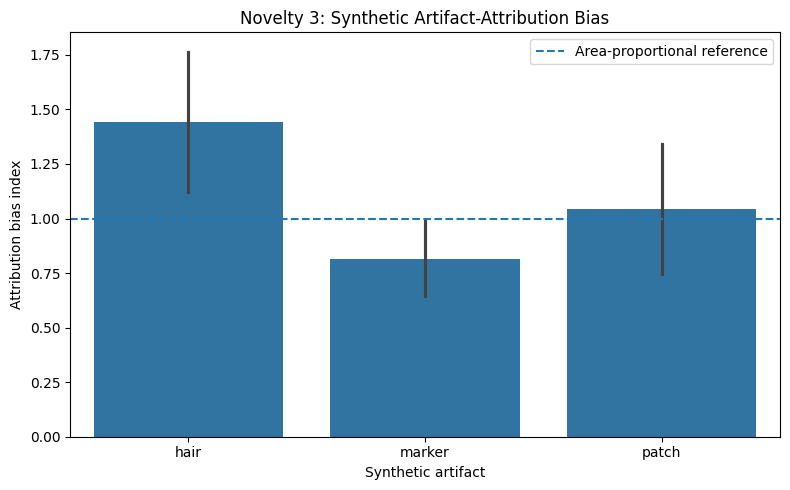

In [23]:
# ============================================================
# CELL 21 — N3 SUMMARY + PLOT
# ============================================================
n3_summary = n3_df.groupby("artifact_type").agg(
    mean_attribution_ratio=("artifact_attribution_ratio","mean"),
    std_attribution_ratio=("artifact_attribution_ratio","std"),
    mean_bias_index=("artifact_bias_index","mean"),
    std_bias_index=("artifact_bias_index","std"),
    mean_probability_change=("target_probability_change","mean"),
    std_probability_change=("target_probability_change","std")
).reset_index()
display(n3_summary)
plt.figure(figsize=(8,5))
sns.barplot(data=n3_df, x="artifact_type", y="artifact_bias_index", errorbar="sd")
plt.axhline(1.0, linestyle="--", label="Area-proportional reference")
plt.xlabel("Synthetic artifact"); plt.ylabel("Attribution bias index")
plt.title("Novelty 3: Synthetic Artifact-Attribution Bias")
plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "novelty3_artifact_bias.png", dpi=300); plt.show()

# NOVELTY 4 — Explanation Stability Under Perturbation

The original perturbation family is retained: brightness, contrast, Gaussian noise, horizontal flip, and 10° rotation. Flip/rotation explanations are aligned back to the original coordinates before similarity is calculated.

In [24]:
# ============================================================
# CELL 22 — N4 FUNCTIONS
# ============================================================
def gaussian_noise(image, sigma=5):
    arr = np.asarray(image).astype(np.float32)
    noise = np.random.normal(0, sigma, arr.shape)
    return Image.fromarray(np.clip(arr + noise, 0, 255).astype(np.uint8))

def perturbations(image):
    return {
        "brightness_down": ImageEnhance.Brightness(image).enhance(.90),
        "brightness_up": ImageEnhance.Brightness(image).enhance(1.10),
        "contrast_down": ImageEnhance.Contrast(image).enhance(.90),
        "contrast_up": ImageEnhance.Contrast(image).enhance(1.10),
        "gaussian_noise": gaussian_noise(image, sigma=5),
        "horizontal_flip": image.transpose(Image.Transpose.FLIP_LEFT_RIGHT),
        "rotation_10": image.rotate(10, resample=Image.Resampling.BILINEAR, expand=False)
    }

def cosine_similarity_map(a,b):
    a=np.asarray(a).reshape(-1); b=np.asarray(b).reshape(-1)
    d=np.linalg.norm(a)*np.linalg.norm(b)
    return float(np.dot(a,b)/d) if d else np.nan

def align_map(m, name):
    if name == "horizontal_flip":
        return np.fliplr(m)
    if name == "rotation_10":
        p=Image.fromarray(np.uint8(np.clip(m,0,1)*255))
        p=p.rotate(-10, resample=Image.Resampling.BILINEAR, expand=False)
        return np.asarray(p).astype(np.float32)/255.0
    return m

def spearman_similarity(a,b):
    v,_=spearmanr(np.asarray(a).reshape(-1), np.asarray(b).reshape(-1))
    return float(v) if np.isfinite(v) else np.nan

In [25]:
# ============================================================
# CELL 23 — N4 EXPERIMENT (ONE BATCH SHAP CALL PER LESION)
# ============================================================
n4_records=[]
for i in tqdm(range(min(N4_IMAGES, len(test_df))), desc="N4 Stability"):
    row=test_df.iloc[i]
    with Image.open(row["image_path"]) as im:
        original=im.convert("RGB")
    original_tensor=eval_transform(original).unsqueeze(0)
    original_pred, original_conf, _=predict_tensor(original_tensor, tta=False)
    original_map=shap_maps(shap_explainer, original_tensor, original_pred)[0]

    perts=perturbations(original)
    names=list(perts.keys())
    batch=torch.stack([eval_transform(perts[n]) for n in names]).to(DEVICE)
    # One SHAP call for all seven perturbations; all use the same target.
    maps=shap_maps(shap_explainer, batch, original_pred)

    for j,name in enumerate(names):
        pred,conf,probs=predict_tensor(batch[j:j+1], tta=False)
        aligned=align_map(maps[j], name)
        n4_records.append({
            "index":i,
            "true_class":row.dx,
            "perturbation":name,
            "original_prediction":original_pred,
            "perturbed_prediction":pred,
            "original_confidence":original_conf,
            "perturbed_target_probability":float(probs[original_pred]),
            "prediction_preserved":int(pred==original_pred),
            "cosine_similarity":cosine_similarity_map(original_map, aligned),
            "spearman_similarity":spearman_similarity(original_map, aligned)
        })

n4_df=pd.DataFrame(n4_records)
n4_df.to_csv(TABLE_DIR / "novelty4_stability.csv", index=False)
display(n4_df)

N4 Stability:   0%|          | 0/3 [00:00<?, ?it/s]

,index,true_class,perturbation,original_prediction,perturbed_prediction,original_confidence,perturbed_target_probability,prediction_preserved,cosine_similarity,spearman_similarity
0,0,bkl,brightness_down,5,5,0.557595,0.604528,1,0.940361,0.751557
1,0,bkl,brightness_up,5,5,0.557595,0.485666,1,0.901292,0.737595
2,0,bkl,contrast_down,5,5,0.557595,0.618662,1,0.874660,0.726687
3,0,bkl,contrast_up,5,5,0.557595,0.531687,1,0.876787,0.726959
4,0,bkl,gaussian_noise,5,5,0.557595,0.386735,1,0.789850,0.570591
5,0,bkl,horizontal_flip,5,5,0.557595,0.587321,1,0.632202,0.413111
6,0,bkl,rotation_10,5,5,0.557595,0.519618,1,0.652080,0.372141
7,1,bkl,brightness_down,5,5,0.799136,0.879892,1,0.919060,0.771294
8,1,bkl,brightness_up,5,5,0.799136,0.781069,1,0.928827,0.733431
9,1,bkl,contrast_down,5,5,0.799136,0.779595,1,0.898040,0.630464


,perturbation,mean_cosine,std_cosine,mean_spearman,std_spearman,prediction_preservation
0,brightness_down,0.928981,0.010725,0.770082,0.017949,1.0
1,brightness_up,0.897506,0.033376,0.730229,0.009385,1.0
2,contrast_down,0.883819,0.012485,0.689164,0.051488,1.0
3,contrast_up,0.888884,0.030312,0.718414,0.021982,1.0
4,gaussian_noise,0.807908,0.048416,0.554915,0.042603,1.0
5,horizontal_flip,0.642594,0.041582,0.303403,0.121868,1.0
6,rotation_10,0.670489,0.051088,0.324434,0.063712,1.0


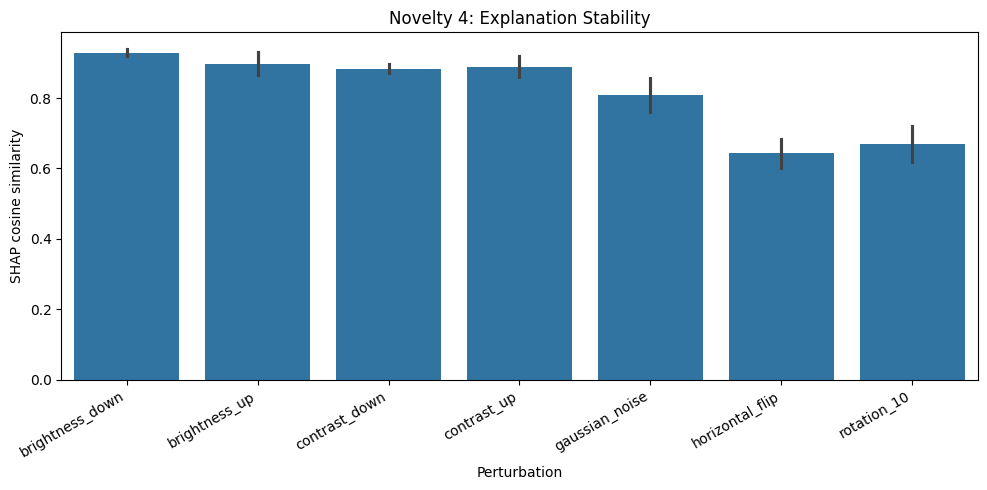

In [26]:
# ============================================================
# CELL 24 — N4 SUMMARY + PLOT
# ============================================================
n4_summary=n4_df.groupby("perturbation").agg(
    mean_cosine=("cosine_similarity","mean"),
    std_cosine=("cosine_similarity","std"),
    mean_spearman=("spearman_similarity","mean"),
    std_spearman=("spearman_similarity","std"),
    prediction_preservation=("prediction_preserved","mean")
).reset_index()
display(n4_summary)
plt.figure(figsize=(10,5))
sns.barplot(data=n4_df, x="perturbation", y="cosine_similarity", errorbar="sd")
plt.xlabel("Perturbation"); plt.ylabel("SHAP cosine similarity")
plt.title("Novelty 4: Explanation Stability")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(FIG_DIR / "novelty4_stability.png", dpi=300); plt.show()

In [27]:
# ============================================================
# CELL 25 — STATISTICS: MEAN, SD, 95% CI + PAIRED TESTS
# ============================================================
def mean_ci(values):
    x=np.asarray(values,dtype=float); x=x[np.isfinite(x)]
    if len(x)==0: return np.nan,np.nan,np.nan,np.nan
    mean=float(x.mean()); std=float(x.std(ddof=1)) if len(x)>1 else 0.0
    sem=std/np.sqrt(len(x)) if len(x)>1 else 0.0
    return mean,std,mean-1.96*sem,mean+1.96*sem

def paired_tests(x,y):
    x=np.asarray(x,dtype=float); y=np.asarray(y,dtype=float)
    valid=np.isfinite(x)&np.isfinite(y); x=x[valid]; y=y[valid]
    out={"n":len(x),"mean_difference":np.nan,"wilcoxon_p":np.nan,"paired_t_p":np.nan}
    if len(x)<2: return out
    out["mean_difference"]=float(np.mean(x-y))
    try: out["wilcoxon_p"]=float(wilcoxon(x,y).pvalue)
    except Exception: pass
    try: out["paired_t_p"]=float(ttest_rel(x,y).pvalue)
    except Exception: pass
    return out

# N1
rows=[]
for metric in ["deletion_auc","insertion_auc"]:
    mean,std,lo,hi=mean_ci(n1_df[metric])
    rows.append({"metric":metric,"n":n1_df[metric].notna().sum(),"mean":mean,"std":std,"ci95_lower":lo,"ci95_upper":hi})
n1_stats=pd.DataFrame(rows); n1_stats.to_csv(TABLE_DIR/"novelty1_statistics.csv",index=False)

# N2
n2_stats=n2_df.groupby("randomized_fraction")["shap_spearman_similarity"].agg(["count","mean","std"]).reset_index()
n2_stats["sem"]=n2_stats["std"]/np.sqrt(n2_stats["count"].clip(lower=1))
n2_stats["ci95_lower"]=n2_stats["mean"]-1.96*n2_stats["sem"]
n2_stats["ci95_upper"]=n2_stats["mean"]+1.96*n2_stats["sem"]
n2_stats.to_csv(TABLE_DIR/"novelty2_statistics.csv",index=False)

# N3
rows=[]
for art in ARTIFACT_TYPES:
    sub=n3_df[n3_df.artifact_type==art]
    for metric in ["artifact_attribution_ratio","artifact_bias_index","target_probability_change"]:
        mean,std,lo,hi=mean_ci(sub[metric])
        rows.append({"artifact_type":art,"metric":metric,"n":sub[metric].notna().sum(),"mean":mean,"std":std,"ci95_lower":lo,"ci95_upper":hi})
n3_stats=pd.DataFrame(rows); n3_stats.to_csv(TABLE_DIR/"novelty3_statistics.csv",index=False)

# N4
rows=[]
for pert in n4_df.perturbation.unique():
    sub=n4_df[n4_df.perturbation==pert]
    for metric in ["cosine_similarity","spearman_similarity","prediction_preserved"]:
        mean,std,lo,hi=mean_ci(sub[metric])
        rows.append({"perturbation":pert,"metric":metric,"n":sub[metric].notna().sum(),"mean":mean,"std":std,"ci95_lower":lo,"ci95_upper":hi})
n4_stats=pd.DataFrame(rows); n4_stats.to_csv(TABLE_DIR/"novelty4_statistics.csv",index=False)

display(n1_stats); display(n2_stats); display(n3_stats); display(n4_stats)

,metric,n,mean,std,ci95_lower,ci95_upper
0,deletion_auc,3,0.420217,0.101732,0.305097,0.535338
1,insertion_auc,3,0.368035,0.058278,0.302087,0.433983


,randomized_fraction,count,mean,std,sem,ci95_lower,ci95_upper
0,0.0,2,1.000000,0.000000,0.000000,1.000000,1.000000
1,0.5,2,0.294831,0.097400,0.068872,0.159842,0.429820
2,1.0,2,0.274483,0.142383,0.100680,0.077149,0.471816


,artifact_type,metric,n,mean,std,ci95_lower,ci95_upper
0,hair,artifact_attribution_ratio,3,0.070382,0.015666,0.052655,0.088110
1,hair,artifact_bias_index,3,1.443787,0.321365,1.080129,1.807445
2,hair,target_probability_change,3,0.103334,0.245647,-0.174642,0.381310
3,marker,artifact_attribution_ratio,3,0.013713,0.002902,0.010429,0.016996
4,marker,artifact_bias_index,3,0.815226,0.172497,0.620026,1.010425
5,marker,target_probability_change,3,0.039225,0.090337,-0.063001,0.141450
6,patch,artifact_attribution_ratio,3,0.059513,0.016891,0.040399,0.078626
7,patch,artifact_bias_index,3,1.043365,0.296126,0.708267,1.378463
8,patch,target_probability_change,3,0.028064,0.101778,-0.087108,0.143236


,perturbation,metric,n,mean,std,ci95_lower,ci95_upper
0,brightness_down,cosine_similarity,3,0.928981,0.010725,0.916844,0.941117
1,brightness_down,spearman_similarity,3,0.770082,0.017949,0.749770,0.790393
2,brightness_down,prediction_preserved,3,1.000000,0.000000,1.000000,1.000000
3,brightness_up,cosine_similarity,3,0.897506,0.033376,0.859737,0.935274
4,brightness_up,spearman_similarity,3,0.730229,0.009385,0.719609,0.740850
5,brightness_up,prediction_preserved,3,1.000000,0.000000,1.000000,1.000000
6,contrast_down,cosine_similarity,3,0.883819,0.012485,0.869691,0.897947
7,contrast_down,spearman_similarity,3,0.689164,0.051488,0.630899,0.747428
8,contrast_down,prediction_preserved,3,1.000000,0.000000,1.000000,1.000000
9,contrast_up,cosine_similarity,3,0.888884,0.030312,0.854583,0.923185


In [28]:
# ============================================================
# CELL 26 — PAIRED COMPARISON EXAMPLES
# ============================================================
def paired_n3(metric, a, b):
    x=n3_df[n3_df.artifact_type==a].set_index("index")[metric]
    y=n3_df[n3_df.artifact_type==b].set_index("index")[metric]
    common=x.index.intersection(y.index)
    return paired_tests(x.loc[common].values, y.loc[common].values)

def paired_n4(metric, a, b):
    x=n4_df[n4_df.perturbation==a].set_index("index")[metric]
    y=n4_df[n4_df.perturbation==b].set_index("index")[metric]
    common=x.index.intersection(y.index)
    return paired_tests(x.loc[common].values, y.loc[common].values)

print("N3 hair vs patch — artifact bias index")
print(paired_n3("artifact_bias_index","hair","patch"))
print("\nN4 brightness-down vs brightness-up — cosine similarity")
print(paired_n4("cosine_similarity","brightness_down","brightness_up"))

N3 hair vs patch — artifact bias index
{'n': 3, 'mean_difference': 0.40042193066906, 'wilcoxon_p': 0.25, 'paired_t_p': 0.006155905737683603}

N4 brightness-down vs brightness-up — cosine similarity
{'n': 3, 'mean_difference': 0.0314750870068868, 'wilcoxon_p': 0.5, 'paired_t_p': 0.2880033769641169}


In [29]:
# ============================================================
# CELL 27 — FINAL RESULT TABLES
# ============================================================
classification_summary=pd.DataFrame([{
    "Accuracy":test_metrics["accuracy"],
    "Macro Precision":test_metrics["macro_precision"],
    "Macro Recall":test_metrics["macro_recall"],
    "Macro F1":test_metrics["macro_f1"],
    "Macro ROC-AUC (OvR)":test_metrics["macro_roc_auc_ovr"],
    "Macro AUPRC":test_metrics["macro_auprc"]
}])
display(classification_summary.style.format("{:.4f}"))
classification_summary.to_csv(TABLE_DIR/"final_classification_summary.csv",index=False)

precision,recall,f1,support=precision_recall_fscore_support(
    test_metrics["y_true"],test_metrics["y_pred"],labels=list(range(NUM_CLASSES)),zero_division=0
)
per_class=pd.DataFrame({"Class":list(class_names.values()),"Precision":precision,"Recall":recall,"F1":f1,"Support":support})
display(per_class.style.format({"Precision":"{:.4f}","Recall":"{:.4f}","F1":"{:.4f}","Support":"{:.0f}"}))
per_class.to_csv(TABLE_DIR/"per_class_performance.csv",index=False)

final_xai_summary=pd.DataFrame([
    {"Novelty":"N1 Faithfulness","Metric":"Deletion AUC","Mean":n1_df.deletion_auc.mean(),"Std":n1_df.deletion_auc.std()},
    {"Novelty":"N1 Faithfulness","Metric":"Insertion AUC","Mean":n1_df.insertion_auc.mean(),"Std":n1_df.insertion_auc.std()},
    {"Novelty":"N2 Randomization","Metric":"Final SHAP Spearman similarity","Mean":n2_df[n2_df.randomized_fraction==max(N2_RANDOMIZATION_LEVELS)].shap_spearman_similarity.mean(),"Std":n2_df[n2_df.randomized_fraction==max(N2_RANDOMIZATION_LEVELS)].shap_spearman_similarity.std()},
    {"Novelty":"N3 Artifact Bias","Metric":"Artifact bias index","Mean":n3_df.artifact_bias_index.mean(),"Std":n3_df.artifact_bias_index.std()},
    {"Novelty":"N4 Stability","Metric":"Cosine similarity","Mean":n4_df.cosine_similarity.mean(),"Std":n4_df.cosine_similarity.std()},
    {"Novelty":"N4 Stability","Metric":"Spearman similarity","Mean":n4_df.spearman_similarity.mean(),"Std":n4_df.spearman_similarity.std()},
    {"Novelty":"N4 Stability","Metric":"Prediction preservation","Mean":n4_df.prediction_preserved.mean(),"Std":n4_df.prediction_preserved.std()}
])
display(final_xai_summary.style.format({"Mean":"{:.4f}","Std":"{:.4f}"}))
final_xai_summary.to_csv(TABLE_DIR/"final_xai_summary.csv",index=False)

,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC (OvR),Macro AUPRC
0,0.8302,0.6914,0.6938,0.6814,0.9612,0.7693


,Class,Precision,Recall,F1,Support
0,Actinic keratoses,0.5574,0.6939,0.6182,49
1,Basal cell carcinoma,0.6591,0.7532,0.7030,77
2,Benign keratosis,0.7956,0.6606,0.7219,165
3,Dermatofibroma,0.7500,0.5294,0.6207,17
4,Melanoma,0.5983,0.4192,0.4930,167
5,Melanocytic nevi,0.8987,0.9433,0.9205,1006
6,Vascular lesions,0.5806,0.8571,0.6923,21


,Novelty,Metric,Mean,Std
0,N1 Faithfulness,Deletion AUC,0.4202,0.1017
1,N1 Faithfulness,Insertion AUC,0.3680,0.0583
2,N2 Randomization,Final SHAP Spearman similarity,0.2745,0.1424
3,N3 Artifact Bias,Artifact bias index,1.1008,0.3621
4,N4 Stability,Cosine similarity,0.8172,0.1140
5,N4 Stability,Spearman similarity,0.5844,0.1930
6,N4 Stability,Prediction preservation,1.0000,0.0000


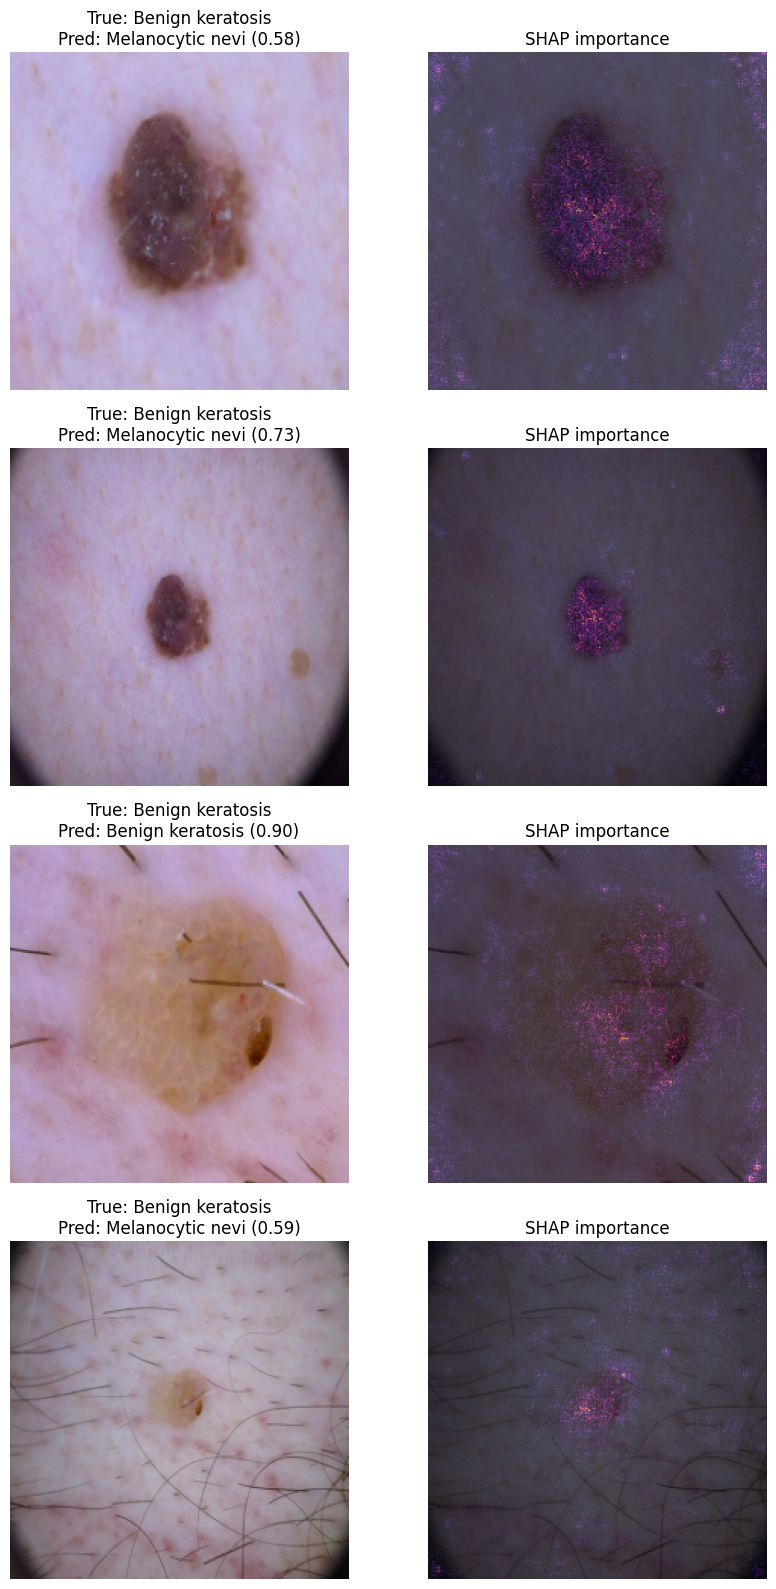

In [30]:
# ============================================================
# CELL 28 — SHAP GALLERY
# ============================================================
gallery_n=min(4,len(test_df))
fig,axes=plt.subplots(gallery_n,2,figsize=(9,4*gallery_n))
if gallery_n==1: axes=np.array([axes])
for r in range(gallery_n):
    row=test_df.iloc[r]
    with Image.open(row["image_path"]) as im:
        tensor=eval_transform(im.convert("RGB")).unsqueeze(0)
    pred,conf,_=predict_tensor(tensor,tta=True)
    m=shap_maps(shap_explainer,tensor,pred)[0]
    visual=denormalize(tensor)
    axes[r,0].imshow(visual); axes[r,0].axis("off")
    axes[r,0].set_title(f"True: {class_names[row.dx]}\nPred: {list(class_names.values())[pred]} ({conf:.2f})")
    axes[r,1].imshow(visual); axes[r,1].imshow(m,alpha=.60,cmap="magma"); axes[r,1].axis("off"); axes[r,1].set_title("SHAP importance")
plt.tight_layout(); plt.savefig(FIG_DIR/"shap_gallery.png",dpi=300); plt.show()

In [31]:
# ============================================================
# CELL 29 — MASTER RESULTS + ZIP
# ============================================================
master_results={
    "model":"EfficientNet-B0",
    "dataset":"HAM10000",
    "test_evaluation":"horizontal-flip TTA",
    "best_validation_macro_f1":best_f1,
    "best_epoch":best_epoch,
    "test_accuracy":test_metrics["accuracy"],
    "test_macro_precision":test_metrics["macro_precision"],
    "test_macro_recall":test_metrics["macro_recall"],
    "test_macro_f1":test_metrics["macro_f1"],
    "test_macro_roc_auc_ovr":test_metrics["macro_roc_auc_ovr"],
    "test_macro_auprc":test_metrics["macro_auprc"],
    "N1_deletion_auc_mean":n1_df.deletion_auc.mean(),
    "N1_insertion_auc_mean":n1_df.insertion_auc.mean(),
    "N2_final_randomization_similarity_mean":n2_df[n2_df.randomized_fraction==max(N2_RANDOMIZATION_LEVELS)].shap_spearman_similarity.mean(),
    "N3_artifact_bias_index_mean":n3_df.artifact_bias_index.mean(),
    "N4_cosine_stability_mean":n4_df.cosine_similarity.mean(),
    "N4_spearman_stability_mean":n4_df.spearman_similarity.mean(),
    "N4_prediction_preservation_mean":n4_df.prediction_preserved.mean()
}
master_df=pd.DataFrame([master_results])
display(master_df.T.rename(columns={0:"Value"}))
master_df.to_csv(TABLE_DIR/"MASTER_RESULTS.csv",index=False)
zip_file=shutil.make_archive("/content/skin_cancer_xai_results","zip",OUTPUT_DIR)
print("Outputs:",OUTPUT_DIR)
print("ZIP:",zip_file)

,Value
model,EfficientNet-B0
dataset,HAM10000
test_evaluation,horizontal-flip TTA
best_validation_macro_f1,0.718612
best_epoch,4
test_accuracy,0.830226
test_macro_precision,0.691385
test_macro_recall,0.693827
test_macro_f1,0.681355
test_macro_roc_auc_ovr,0.961171


Outputs: /content/skin_cancer_xai_outputs
ZIP: /content/skin_cancer_xai_results.zip


## Publication checklist

- Report the exact lesion-grouped split and random seed.
- Report both single-view and TTA classification results.
- Use Macro-F1, per-class metrics, AUROC and AUPRC; do not rely on accuracy alone.
- Report mean ± SD / 95% CI for all four novelty experiments.
- For N1, compare against appropriate attribution baselines in a final expanded study if possible.
- For N2, decreasing similarity with increasing randomization supports model dependence.
- For N3, bias index > 1 indicates disproportionate attribution relative to artifact area; it does not by itself prove clinical bias.
- For N4, report similarity together with prediction preservation.
- Do not claim universal clinical validity from SHAP faithfulness/stability experiments.

### Four preserved novelties
1. **Faithfulness Evaluation — Insertion/Deletion AUC**
2. **Model-Randomization Sanity Check**
3. **Synthetic Artifact-Attribution Bias Testing**
4. **Explanation Stability Under Perturbation**

ABCD analysis output directory:
/content/skin_cancer_xai_outputs/ABCD_analysis

Starting ABCD analysis...
This does NOT rerun model training or SHAP.



ABCD analysis:   0%|          | 0/1502 [00:00<?, ?it/s]


ABCD analysis completed.
Successfully analyzed: 1502 / 1502 images

Saved:
/content/skin_cancer_xai_outputs/ABCD_analysis/ABCD_features_test.csv
Saved:
/content/skin_cancer_xai_outputs/ABCD_analysis/ABCD_classwise_summary.csv

===== ABCD SAMPLE RESULTS =====


,index,image_id,true_class,A_asymmetry,B_border_irregularity,C_color_variation,D_diameter_px,lesion_area_px,lesion_area_fraction,E_evolution
0,0,ISIC_0027828,bkl,0.193908,1.306139,31.345798,103.540702,8420.0,0.167809,Not assessable from single image
1,1,ISIC_0029291,bkl,0.230088,1.343606,24.168276,45.135167,1600.0,0.031888,Not assessable from single image
2,2,ISIC_0031753,bkl,0.307089,1.813075,25.368246,120.683831,11439.0,0.227978,Not assessable from single image
3,3,ISIC_0026835,bkl,0.782115,10.556807,34.768742,135.461907,14412.0,0.287229,Not assessable from single image
4,4,ISIC_0028052,bkl,0.533250,3.149343,29.578558,54.816469,2360.0,0.047034,Not assessable from single image
5,5,ISIC_0024698,nv,0.415079,1.447418,28.512140,49.352885,1913.0,0.038126,Not assessable from single image
6,6,ISIC_0025063,bkl,0.314349,2.963953,33.019054,69.722511,3818.0,0.076092,Not assessable from single image
7,7,ISIC_0029418,bkl,0.467932,1.517958,44.325748,87.199694,5972.0,0.119021,Not assessable from single image
8,8,ISIC_0027455,bkl,0.468130,1.482106,42.214012,52.478730,2163.0,0.043108,Not assessable from single image
9,9,ISIC_0032929,bkl,0.343951,5.705975,22.365011,202.294815,32141.0,0.640565,Not assessable from single image



===== CLASS-WISE ABCD SUMMARY =====


A_asymmetry                       B_border_irregularity          \
                  mean     std  median count                  mean     std   
true_class                                                                   
akiec           0.5046  0.1571  0.4992    49                4.8195  2.6619   
bcc             0.4879  0.1744  0.5125    76                4.1276  2.0537   
bkl             0.4281  0.1907  0.4451   165                3.7882  2.5787   
df              0.2721  0.1261  0.2552    17                2.2266  1.6054   
mel             0.3563  0.1799  0.3131   167                2.7488  2.0503   
nv              0.2982  0.1421  0.2675  1006                2.0601  1.2969   
vasc            0.2733  0.1653  0.2323    21                2.2164  2.6704   

                         C_color_variation                          \
            median count              mean      std   median count   
true_class                                                           
akiec       4.3158    49           28.3508   9.8762  27.7253    49   
bcc         3.6620    76           29.3645  11.8355  26.3358    76   
bkl         2.8177   165           29.7607   9.9516  28.3997   165   
df          1.7712    17           24.5830   8.1429  24.0725    17   
mel         1.8732   167           36.4669   9.8411  35.6982   167   
nv          1.6733  1006           31.9294   9.4433  30.6464  1006   
vasc        1.3516    21           32.0611  13.0976  27.8692    21   

           D_diameter_px                           
                    mean      std    median count  
true_class                                         
akiec           127.4519  53.6304  141.4440    49  
bcc             112.9238  49.2026  123.5977    76  
bkl             117.4575  45.2975  121.6820   165  
df              115.9812  49.2875  119.8422    17  
mel             114.9014  38.8402  118.4798   167  
nv              104.5060  40.3376  102.3751  1006  
vasc             92.8269  43.3697   88.3241    21


===== OVERALL STATISTICS =====


,count,mean,std,min,25%,50%,75%,max
A_asymmetry,1501.0,0.334665,0.167542,0.045965,0.202039,0.296970,0.445193,0.947661
B_border_irregularity,1501.0,2.525528,1.873461,1.158585,1.516206,1.763593,2.587647,14.639503
C_color_variation,1501.0,31.867774,9.928879,7.899404,24.943560,30.570377,37.555611,74.031937
D_diameter_px,1501.0,108.228127,42.265128,25.357168,75.052060,106.946299,139.312564,214.679882


<Figure size 1000x600 with 0 Axes>

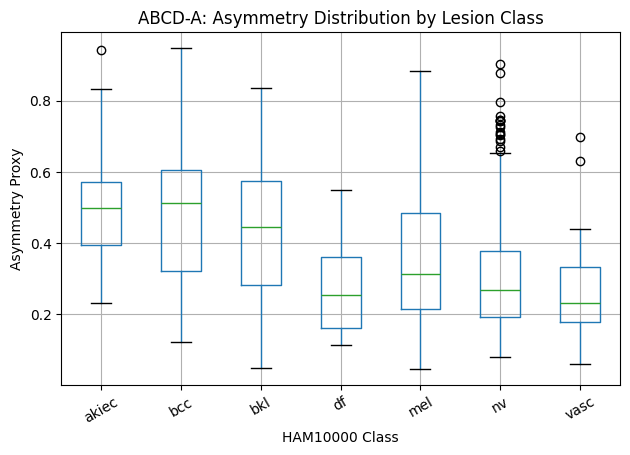

<Figure size 1000x600 with 0 Axes>

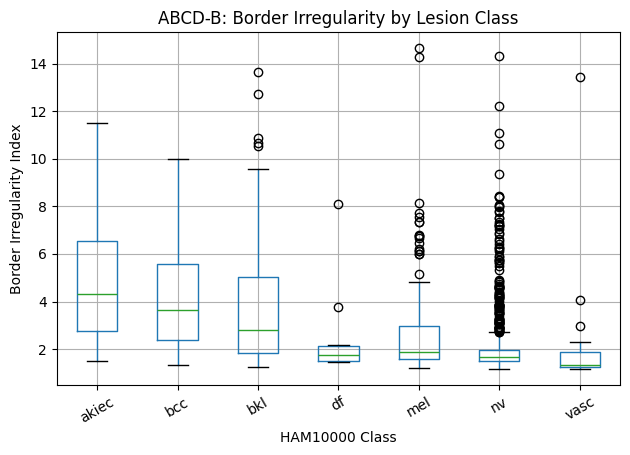

<Figure size 1000x600 with 0 Axes>

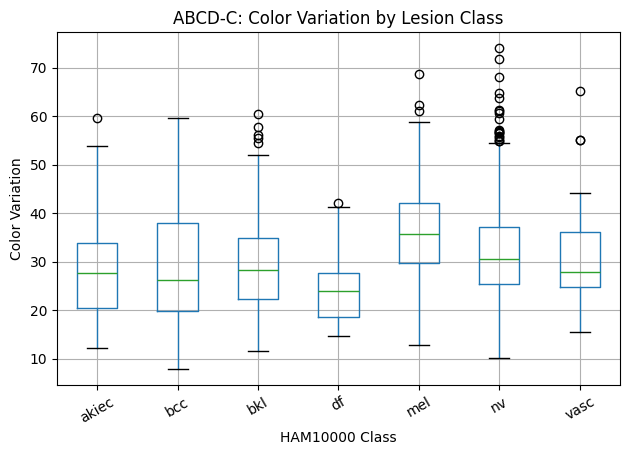

<Figure size 1000x600 with 0 Axes>

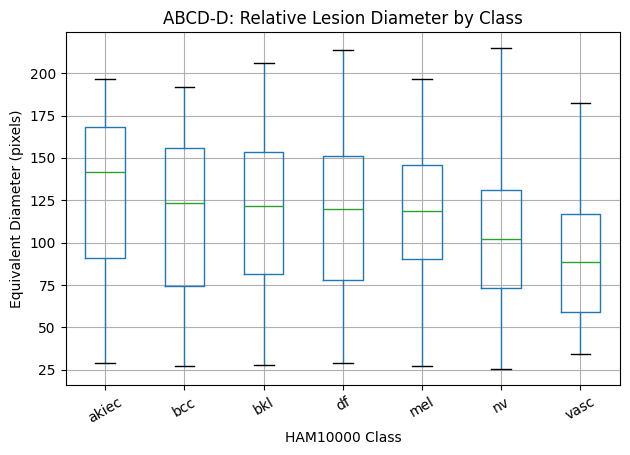


ABCD ANALYSIS COMPLETE

A — Asymmetry
    Computed from similarity between the lesion mask
    and its horizontally mirrored version.

B — Border
    Estimated using a compactness/border-irregularity index.

C — Color
    Estimated from within-lesion RGB color dispersion.

D — Diameter
    Reported as equivalent diameter in pixels.
    Physical diameter in millimeters requires image calibration.

E — Evolution
    Not assessable from a single static HAM10000 image.

IMPORTANT:
These are computational image-derived proxies and should
not be interpreted as an automated clinical ABCDE diagnosis.


Files generated:
1. /content/skin_cancer_xai_outputs/ABCD_analysis/ABCD_features_test.csv
2. /content/skin_cancer_xai_outputs/ABCD_analysis/ABCD_classwise_summary.csv
3. /content/skin_cancer_xai_outputs/ABCD_analysis/ABCD_overall_statistics.csv
4. /content/skin_cancer_xai_outputs/ABCD_analysis/ABCD_A_asymmetry.png
5. /content/skin_cancer_xai_outputs/ABCD_analysis/ABCD_B_border_irregularity.png


In [32]:
# ============================================================
# FINAL ADD-ON: COMPUTATIONAL ABCD CLINICAL FEATURE ANALYSIS
# ============================================================
# IMPORTANT:
# - Does NOT modify EfficientNet-B0
# - Does NOT retrain the model
# - Does NOT rerun SHAP
# - Does NOT modify N1, N2, N3, or N4
# - Uses the existing test_df
# - A-D are image-derived proxies
# - E (Evolution) cannot be assessed from a single static image
# - Diameter is reported in pixels, NOT millimeters
# ============================================================

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create separate output directory
# ------------------------------------------------------------

ABCD_DIR = Path(OUTPUT_DIR) / "ABCD_analysis"
ABCD_DIR.mkdir(parents=True, exist_ok=True)

print("ABCD analysis output directory:")
print(ABCD_DIR)


# ------------------------------------------------------------
# 2. Estimate lesion mask
# ------------------------------------------------------------

def estimate_lesion_mask(rgb):
    """
    Research-oriented automatic lesion-mask estimation.

    NOTE:
    This is NOT a clinical-grade segmentation algorithm.
    It is only used to derive approximate ABCD image features.
    """

    img = np.asarray(rgb).copy()

    # Convert color spaces
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    L = lab[:, :, 0]
    S = hsv[:, :, 1]

    # Darker-than-background candidate
    _, dark = cv2.threshold(
        L,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Saturation candidate
    sat_threshold = np.percentile(S, 45)
    sat = (S > sat_threshold).astype(np.uint8) * 255

    # Combine
    mask = cv2.bitwise_and(dark, sat)

    # Morphological cleaning
    kernel = np.ones((5, 5), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # Connected components
    n, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    h, w = mask.shape

    candidates = []

    for k in range(1, n):

        area = stats[k, cv2.CC_STAT_AREA]

        cx, cy = centroids[k]

        # Ignore extremely small / huge components
        if area < 0.01 * h * w:
            continue

        if area > 0.75 * h * w:
            continue

        # Prefer components near image center
        distance = np.sqrt(
            (cx - w / 2) ** 2 +
            (cy - h / 2) ** 2
        )

        candidates.append(
            (distance, -area, k)
        )

    if len(candidates) == 0:
        return np.zeros(
            (h, w),
            dtype=np.uint8
        )

    # Closest large central component
    _, _, best_component = sorted(candidates)[0]

    final_mask = (
        labels == best_component
    ).astype(np.uint8)

    return final_mask


# ------------------------------------------------------------
# 3. Calculate ABCD features
# ------------------------------------------------------------

def calculate_abcd_features(rgb, mask):

    h, w = mask.shape

    area = float(mask.sum())

    # Invalid / very small lesion
    if area < 50:

        return {
            "A_asymmetry": np.nan,
            "B_border_irregularity": np.nan,
            "C_color_variation": np.nan,
            "D_diameter_px": np.nan,
            "lesion_area_px": np.nan,
            "lesion_area_fraction": np.nan,
            "E_evolution": "Not assessable from single image"
        }

    # --------------------------------------------------------
    # A — Asymmetry
    # --------------------------------------------------------

    ys, xs = np.where(mask > 0)

    cx = xs.mean()
    cy = ys.mean()

    # Translate lesion centroid to image center
    dx = int(round(w / 2 - cx))
    dy = int(round(h / 2 - cy))

    translation_matrix = np.float32([
        [1, 0, dx],
        [0, 1, dy]
    ])

    centered_mask = cv2.warpAffine(
        mask.astype(np.uint8),
        translation_matrix,
        (w, h),
        flags=cv2.INTER_NEAREST
    )

    # Horizontal mirror
    flipped_mask = np.fliplr(centered_mask)

    intersection = np.logical_and(
        centered_mask,
        flipped_mask
    ).sum()

    union = np.logical_or(
        centered_mask,
        flipped_mask
    ).sum()

    if union > 0:
        iou = intersection / union
        asymmetry = 1.0 - iou
    else:
        asymmetry = np.nan


    # --------------------------------------------------------
    # B — Border irregularity
    # --------------------------------------------------------

    contours, _ = cv2.findContours(
        (mask * 255).astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:

        border_irregularity = np.nan

    else:

        contour = max(
            contours,
            key=cv2.contourArea
        )

        perimeter = cv2.arcLength(
            contour,
            True
        )

        contour_area = cv2.contourArea(
            contour
        )

        if contour_area > 0:

            border_irregularity = (
                perimeter ** 2
            ) / (
                4 * np.pi * contour_area
            )

        else:

            border_irregularity = np.nan


    # --------------------------------------------------------
    # C — Color variation
    # --------------------------------------------------------

    lesion_pixels = rgb[
        mask > 0
    ].astype(np.float32)

    mean_color = lesion_pixels.mean(
        axis=0
    )

    color_distances = np.linalg.norm(
        lesion_pixels -
        mean_color[None, :],
        axis=1
    )

    color_variation = float(
        color_distances.mean()
    )


    # --------------------------------------------------------
    # D — Diameter
    # --------------------------------------------------------

    # Equivalent circular diameter
    diameter_px = np.sqrt(
        4.0 * area / np.pi
    )


    # --------------------------------------------------------
    # E — Evolution
    # --------------------------------------------------------

    # Cannot be obtained from one static HAM10000 image
    evolution = (
        "Not assessable from single image"
    )


    return {

        "A_asymmetry": float(asymmetry),

        "B_border_irregularity":
            float(border_irregularity),

        "C_color_variation":
            float(color_variation),

        "D_diameter_px":
            float(diameter_px),

        "lesion_area_px":
            float(area),

        "lesion_area_fraction":
            float(area / (h * w)),

        "E_evolution":
            evolution
    }


# ------------------------------------------------------------
# 4. Run ABCD analysis on EXISTING TEST SET
# ------------------------------------------------------------

abcd_records = []

print("\nStarting ABCD analysis...")
print("This does NOT rerun model training or SHAP.\n")

for i, row in tqdm(
    test_df.reset_index(drop=True).iterrows(),
    total=len(test_df),
    desc="ABCD analysis"
):

    try:

        # Load existing test image
        with Image.open(
            row["image_path"]
        ) as im:

            rgb = np.asarray(
                im.convert("RGB").resize(
                    (224, 224)
                )
            )

        # Lesion segmentation
        mask = estimate_lesion_mask(
            rgb
        )

        # ABCD features
        features = calculate_abcd_features(
            rgb,
            mask
        )

        # Save record
        record = {
            "index": i,
            "image_id": row["image_id"],
            "true_class": row["dx"],
            **features
        }

        abcd_records.append(record)

    except Exception as e:

        print(
            f"Warning: failed for index {i}: {e}"
        )


# ------------------------------------------------------------
# 5. Create dataframe
# ------------------------------------------------------------

abcd_df = pd.DataFrame(
    abcd_records
)

print("\nABCD analysis completed.")

print(
    f"Successfully analyzed: "
    f"{len(abcd_df)} / {len(test_df)} images"
)


# ------------------------------------------------------------
# 6. Save complete ABCD results
# ------------------------------------------------------------

ABCD_RESULTS_PATH = (
    ABCD_DIR /
    "ABCD_features_test.csv"
)

abcd_df.to_csv(
    ABCD_RESULTS_PATH,
    index=False
)

print(
    "\nSaved:"
)
print(
    ABCD_RESULTS_PATH
)


# ------------------------------------------------------------
# 7. Class-wise statistical summary
# ------------------------------------------------------------

numeric_abcd = [
    "A_asymmetry",
    "B_border_irregularity",
    "C_color_variation",
    "D_diameter_px"
]

abcd_summary = (
    abcd_df
    .groupby("true_class")[numeric_abcd]
    .agg(["mean", "std", "median", "count"])
    .round(4)
)

ABCD_SUMMARY_PATH = (
    ABCD_DIR /
    "ABCD_classwise_summary.csv"
)

abcd_summary.to_csv(
    ABCD_SUMMARY_PATH
)

print(
    "Saved:"
)
print(
    ABCD_SUMMARY_PATH
)


# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------

print("\n===== ABCD SAMPLE RESULTS =====")

display(
    abcd_df.head(10)
)

print("\n===== CLASS-WISE ABCD SUMMARY =====")

display(
    abcd_summary
)


# ------------------------------------------------------------
# 9. Overall descriptive statistics
# ------------------------------------------------------------

overall_abcd = (
    abcd_df[numeric_abcd]
    .describe()
    .T
)

OVERALL_PATH = (
    ABCD_DIR /
    "ABCD_overall_statistics.csv"
)

overall_abcd.to_csv(
    OVERALL_PATH
)

print(
    "\n===== OVERALL STATISTICS ====="
)

display(
    overall_abcd
)


# ------------------------------------------------------------
# 10. Visualization — A
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

abcd_df.boxplot(
    column="A_asymmetry",
    by="true_class"
)

plt.title(
    "ABCD-A: Asymmetry Distribution by Lesion Class"
)

plt.suptitle("")

plt.xlabel(
    "HAM10000 Class"
)

plt.ylabel(
    "Asymmetry Proxy"
)

plt.xticks(rotation=30)

plt.tight_layout()

A_FIG = (
    ABCD_DIR /
    "ABCD_A_asymmetry.png"
)

plt.savefig(
    A_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 11. Visualization — B
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

abcd_df.boxplot(
    column="B_border_irregularity",
    by="true_class"
)

plt.title(
    "ABCD-B: Border Irregularity by Lesion Class"
)

plt.suptitle("")

plt.xlabel(
    "HAM10000 Class"
)

plt.ylabel(
    "Border Irregularity Index"
)

plt.xticks(rotation=30)

plt.tight_layout()

B_FIG = (
    ABCD_DIR /
    "ABCD_B_border_irregularity.png"
)

plt.savefig(
    B_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 12. Visualization — C
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

abcd_df.boxplot(
    column="C_color_variation",
    by="true_class"
)

plt.title(
    "ABCD-C: Color Variation by Lesion Class"
)

plt.suptitle("")

plt.xlabel(
    "HAM10000 Class"
)

plt.ylabel(
    "Color Variation"
)

plt.xticks(rotation=30)

plt.tight_layout()

C_FIG = (
    ABCD_DIR /
    "ABCD_C_color_variation.png"
)

plt.savefig(
    C_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 13. Visualization — D
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

abcd_df.boxplot(
    column="D_diameter_px",
    by="true_class"
)

plt.title(
    "ABCD-D: Relative Lesion Diameter by Class"
)

plt.suptitle("")

plt.xlabel(
    "HAM10000 Class"
)

plt.ylabel(
    "Equivalent Diameter (pixels)"
)

plt.xticks(rotation=30)

plt.tight_layout()

D_FIG = (
    ABCD_DIR /
    "ABCD_D_diameter.png"
)

plt.savefig(
    D_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 14. Final interpretation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ABCD ANALYSIS COMPLETE")
print("=" * 60)

print("""
A — Asymmetry
    Computed from similarity between the lesion mask
    and its horizontally mirrored version.

B — Border
    Estimated using a compactness/border-irregularity index.

C — Color
    Estimated from within-lesion RGB color dispersion.

D — Diameter
    Reported as equivalent diameter in pixels.
    Physical diameter in millimeters requires image calibration.

E — Evolution
    Not assessable from a single static HAM10000 image.

IMPORTANT:
These are computational image-derived proxies and should
not be interpreted as an automated clinical ABCDE diagnosis.
""")

print("\nFiles generated:")
print("1.", ABCD_RESULTS_PATH)
print("2.", ABCD_SUMMARY_PATH)
print("3.", OVERALL_PATH)
print("4.", A_FIG)
print("5.", B_FIG)
print("6.", C_FIG)
print("7.", D_FIG)